# Production-Grade DistilBERT Fine-Tuning for Marketing Sentiment Analysis

## Purpose
Fine-tune `distilbert-base-uncased` on marketing product review data using **production-standard practices**:
- Data quality audit and remediation
- Class imbalance handling (oversampling, class weights, focal loss)
- Early stopping with patience
- Catastrophic forgetting evaluation
- Overfitting detection (train vs val divergence)
- Calibration analysis and per-class evaluation
- Export format ready for multi-agentic system integration

## Dataset
Amazon product reviews (marketing domain) with 3-class sentiment: negative, neutral, positive.

## Output
A production-ready model artifact with inference wrapper, ready to plug into an agentic pipeline.

---
## Phase 1: Environment Setup & Reproducibility

In [2]:
import os
import json
import random
import warnings
import inspect
import time
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from tqdm.auto import tqdm
from datasets import Dataset, DatasetDict, ClassLabel

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

print(f"Notebook started: {datetime.now().isoformat()}")

/opt/homebrew/Caskroom/miniconda/base/envs/agentic/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0).
W0527 20:18:35.511000 60955 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Notebook started: 2026-05-27T20:18:35.986486


In [3]:
SEED = 42


def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


set_seed()

# --- M4 Parallelism Configuration ---
TOTAL_CORES = os.cpu_count() or 12
# Reserve 1 core for OS/notebook; use the rest for compute
N_CORES = max(1, TOTAL_CORES - 1)

# OpenMP/MKL threading — controls BLAS and DistilBERT's attention ops on CPU fallback
os.environ["OMP_NUM_THREADS"] = str(N_CORES)
os.environ["MKL_NUM_THREADS"] = str(N_CORES)

# Enable parallel tokenization (safe for .map() with num_proc, NOT for DataLoader fork)
os.environ["TOKENIZERS_PARALLELISM"] = "true"

# MPS fallback for ops not yet implemented on Apple GPU
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# PyTorch intra-op threads (matrix multiplies, etc.)
torch.set_num_threads(N_CORES)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print(f"PyTorch: {torch.__version__}")
print(f"Device: {DEVICE}")
print(f"CPU cores: {TOTAL_CORES} (using {N_CORES} for compute)")
print(f"Torch threads: {torch.get_num_threads()}")
print(f"MPS: {torch.backends.mps.is_available()}, CUDA: {torch.cuda.is_available()}")

PyTorch: 2.10.0
Device: mps
CPU cores: 10 (using 9 for compute)
Torch threads: 9
MPS: True, CUDA: False


In [9]:
cwd = Path.cwd().parent
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent

with open(PROJECT_ROOT / "configs" / "config.yaml", "r") as f:
    project_config = yaml.safe_load(f)

BASE_MODEL_ID = "distilbert-base-uncased"

EXPERIMENT_NAME = "distilbert_sentiment_production"
ARTIFACT_DIR = PROJECT_ROOT / "experimentation" / "artifacts" / EXPERIMENT_NAME
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

NUM_LABELS = 3
LABEL_NAMES = ["negative", "neutral", "positive"]
ID2LABEL = {i: name for i, name in enumerate(LABEL_NAMES)}
LABEL2ID = {name: i for i, name in enumerate(LABEL_NAMES)}

CONFIG = {
    "experiment_name": EXPERIMENT_NAME,
    "base_model": BASE_MODEL_ID,
    "hf_cache_dir": str(PROJECT_ROOT / "models" / "hf_cache"),
    "hf_token_env": "HF_TOKEN",
    "num_labels": NUM_LABELS,
    "max_length": 128,               # mean token length is 106; 128 covers 92%+ with less padding waste
    "num_epochs": 10,
    "learning_rate": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "max_grad_norm": 1.0,
    "train_batch_size": 32,           # conservative default for 20GB Macs
    "eval_batch_size": 64,            # safe eval throughput on 20GB Macs
    "early_stopping_patience": 3,
    "early_stopping_threshold": 0.001,
    "seed": SEED,
    # Data
    "data_dir": str(PROJECT_ROOT / "data" / "processed" / "sentiment"),
    "max_train_samples": None,       # None = use all, set int for quick runs
    "max_eval_samples": None,
    # Class imbalance
    "use_class_weights": True,
    "use_focal_loss": False,          # toggle: focal loss vs weighted CE
    "focal_loss_gamma": 2.0,
    # Forgetting evaluation
    "forgetting_eval_samples": 500,
    # --- MPS-optimised parallelism ---
    "tokenize_num_proc": min(4, N_CORES),         # parallel tokenization (pre-training, CPU-bound)
    "dataloader_num_workers": 0,                   # MPS: workers add IPC overhead without GPU benefit
    "gradient_accumulation_steps": 1,              # no accumulation needed at batch_size=64
}

print("Project root:", PROJECT_ROOT)
print("Artifact dir:", ARTIFACT_DIR)
print()
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Project root: /Users/jatindersingh/work_data/mkt-ai
Artifact dir: /Users/jatindersingh/work_data/mkt-ai/experimentation/artifacts/distilbert_sentiment_production

  experiment_name: distilbert_sentiment_production
  base_model: distilbert-base-uncased
  hf_cache_dir: /Users/jatindersingh/work_data/mkt-ai/models/hf_cache
  hf_token_env: HF_TOKEN
  num_labels: 3
  max_length: 128
  num_epochs: 10
  learning_rate: 2e-05
  weight_decay: 0.01
  warmup_ratio: 0.1
  max_grad_norm: 1.0
  train_batch_size: 32
  eval_batch_size: 64
  early_stopping_patience: 3
  early_stopping_threshold: 0.001
  seed: 42
  data_dir: /Users/jatindersingh/work_data/mkt-ai/data/processed/sentiment
  max_train_samples: None
  max_eval_samples: None
  use_class_weights: True
  use_focal_loss: False
  focal_loss_gamma: 2.0
  forgetting_eval_samples: 500
  tokenize_num_proc: 4
  dataloader_num_workers: 0
  gradient_accumulation_steps: 1


---
## Phase 2: Data Quality Audit

Before training, we systematically check for issues that silently degrade model quality:
1. **Missing values** — incomplete records
2. **Duplicates** — inflated metrics and data leakage between splits
3. **Class distribution** — imbalance detection with imbalance ratio
4. **Text quality** — length distribution, empty/near-empty texts
5. **Label noise** — score-sentiment consistency
6. **Cross-split leakage** — same text appearing in train and test

In [11]:
data_dir = Path(CONFIG["data_dir"])

df_train = pd.read_csv(data_dir / "sentiment_train.csv")
df_val = pd.read_csv(data_dir / "sentiment_val.csv")
df_test = pd.read_csv(data_dir / "sentiment_test.csv")

print(f"Train: {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}")
print(f"Total: {len(df_train) + len(df_val) + len(df_test):,}")
print(f"Columns: {list(df_train.columns)}")

Train: 72,000  |  Val: 9,000  |  Test: 9,000
Total: 90,000
Columns: ['CleanText', 'Sentiment', 'Score', 'TextLength', 'WordCount']


In [12]:
def data_quality_report(df: pd.DataFrame, name: str) -> dict:
    """Run comprehensive quality checks on a text classification dataset."""
    report = {"split": name, "n_rows": len(df)}

    # 1. Missing values
    nulls = df[["CleanText", "Sentiment"]].isnull().sum()
    report["null_text"] = int(nulls["CleanText"])
    report["null_label"] = int(nulls["Sentiment"])

    # 2. Duplicates
    report["duplicate_texts"] = int(df["CleanText"].duplicated().sum())
    report["duplicate_pct"] = round(report["duplicate_texts"] / len(df) * 100, 2)

    # 3. Class distribution
    class_counts = df["Sentiment"].value_counts()
    report["class_counts"] = class_counts.to_dict()
    majority = class_counts.max()
    minority = class_counts.min()
    report["imbalance_ratio"] = round(majority / minority, 2)

    # 4. Text length
    lengths = df["CleanText"].str.len()
    report["text_len_mean"] = round(lengths.mean(), 1)
    report["text_len_median"] = round(lengths.median(), 1)
    report["text_len_p95"] = round(lengths.quantile(0.95), 1)
    report["empty_or_short"] = int((lengths < 20).sum())

    return report


reports = []
for df, name in [(df_train, "train"), (df_val, "val"), (df_test, "test")]:
    r = data_quality_report(df, name)
    reports.append(r)
    print(f"\n{'='*60}")
    print(f"  {name.upper()} SPLIT QUALITY REPORT")
    print(f"{'='*60}")
    for k, v in r.items():
        if k != "class_counts":
            print(f"  {k:25s}: {v}")
    print(f"  {'class_counts':25s}:")
    for cls, cnt in r["class_counts"].items():
        pct = cnt / r["n_rows"] * 100
        print(f"    {cls:12s}: {cnt:6d} ({pct:.1f}%)")


  TRAIN SPLIT QUALITY REPORT
  split                    : train
  n_rows                   : 72000
  null_text                : 0
  null_label               : 0
  duplicate_texts          : 10967
  duplicate_pct            : 15.23
  imbalance_ratio          : 1.0
  text_len_mean            : 490.5
  text_len_median          : 354.0
  text_len_p95             : 1286.0
  empty_or_short           : 0
  class_counts             :
    positive    :  24000 (33.3%)
    neutral     :  24000 (33.3%)
    negative    :  24000 (33.3%)

  VAL SPLIT QUALITY REPORT
  split                    : val
  n_rows                   : 9000
  null_text                : 0
  null_label               : 0
  duplicate_texts          : 289
  duplicate_pct            : 3.21
  imbalance_ratio          : 1.0
  text_len_mean            : 494.0
  text_len_median          : 353.5
  text_len_p95             : 1304.0
  empty_or_short           : 0
  class_counts             :
    neutral     :   3000 (33.3%)
    positive  

In [13]:
# Cross-split leakage check
train_texts = set(df_train["CleanText"].values)
val_texts = set(df_val["CleanText"].values)
test_texts_set = set(df_test["CleanText"].values)

leak_train_val = len(train_texts & val_texts)
leak_train_test = len(train_texts & test_texts_set)
leak_val_test = len(val_texts & test_texts_set)

print("Cross-Split Leakage Detection:")
print(f"  Train ∩ Val:  {leak_train_val:,} texts")
print(f"  Train ∩ Test: {leak_train_test:,} texts")
print(f"  Val ∩ Test:   {leak_val_test:,} texts")

if leak_train_test > 0 or leak_train_val > 0:
    print("\n  ⚠ LEAKAGE DETECTED — will deduplicate before training.")
else:
    print("\n  ✓ No cross-split leakage.")

Cross-Split Leakage Detection:
  Train ∩ Val:  1,881 texts
  Train ∩ Test: 1,840 texts
  Val ∩ Test:   495 texts

  ⚠ LEAKAGE DETECTED — will deduplicate before training.


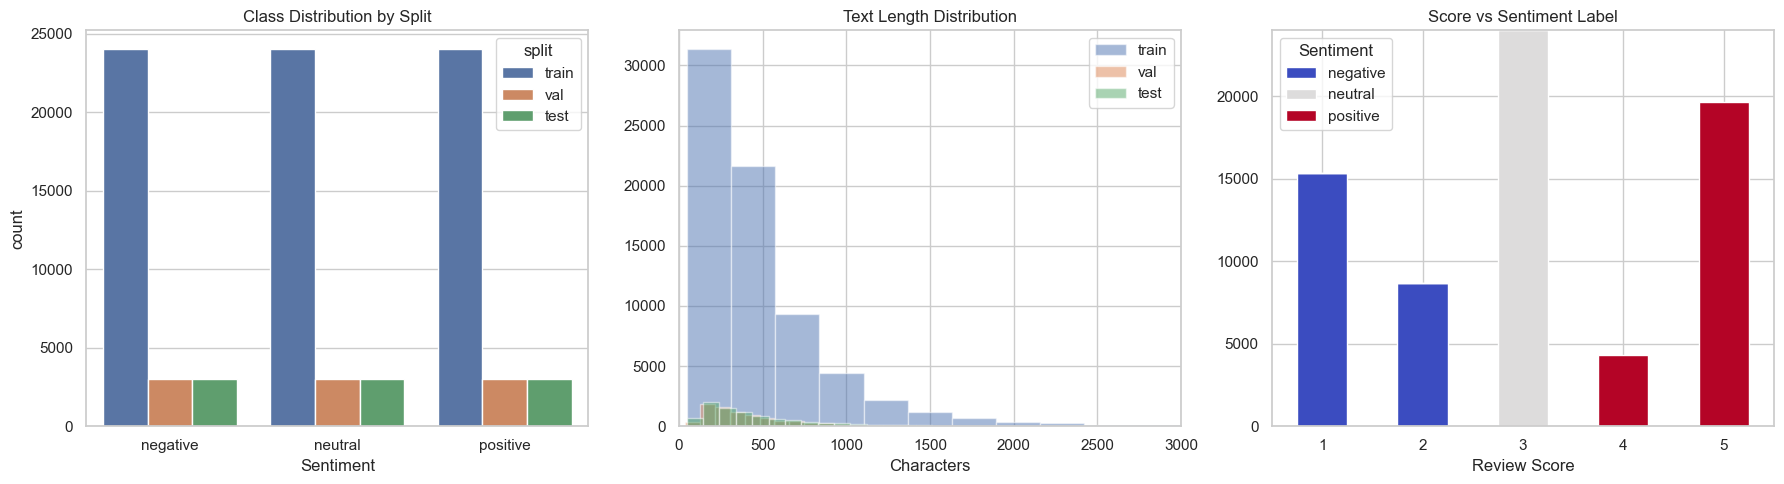

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Class distribution
all_df = pd.concat([
    df_train.assign(split="train"),
    df_val.assign(split="val"),
    df_test.assign(split="test"),
])
sns.countplot(data=all_df, x="Sentiment", hue="split",
              order=LABEL_NAMES, ax=axes[0])
axes[0].set_title("Class Distribution by Split")
axes[0].set_xlabel("Sentiment")

# 2. Text length distribution
for split_name, df_s in [("train", df_train), ("val", df_val), ("test", df_test)]:
    axes[1].hist(df_s["CleanText"].str.len(), bins=80, alpha=0.5, label=split_name)
axes[1].set_title("Text Length Distribution")
axes[1].set_xlabel("Characters")
axes[1].set_xlim(0, 3000)
axes[1].legend()

# 3. Score vs Sentiment sanity check
if "Score" in df_train.columns:
    ct = pd.crosstab(df_train["Score"], df_train["Sentiment"])
    ct.plot(kind="bar", stacked=True, ax=axes[2], colormap="coolwarm")
    axes[2].set_title("Score vs Sentiment Label")
    axes[2].set_xlabel("Review Score")
    axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "data_quality_overview.png", dpi=150, bbox_inches="tight")
plt.show()

### Data Remediation

Based on the audit above, we apply fixes:
1. Remove exact-duplicate texts within each split
2. Remove cross-split leaked texts from train (keep test/val intact)
3. Drop empty or extremely short texts (< 20 chars)
4. Encode labels to integer IDs

In [15]:
def remediate_split(df: pd.DataFrame, name: str, remove_texts: set = None) -> pd.DataFrame:
    n_before = len(df)

    # Drop nulls
    df = df.dropna(subset=["CleanText", "Sentiment"])

    # Drop very short texts
    df = df[df["CleanText"].str.len() >= 20].copy()

    # Drop within-split duplicates
    df = df.drop_duplicates(subset=["CleanText"], keep="first")

    # Remove leaked texts
    if remove_texts:
        df = df[~df["CleanText"].isin(remove_texts)]

    # Encode labels
    df["label"] = df["Sentiment"].map(LABEL2ID)

    n_after = len(df)
    print(f"  {name}: {n_before:,} → {n_after:,} (removed {n_before - n_after:,})")
    return df.reset_index(drop=True)


# Build leak sets — remove from train only (preserve test/val integrity)
leak_from_train = (train_texts & val_texts) | (train_texts & test_texts_set)

print("Remediating splits:")
df_train_clean = remediate_split(df_train, "train", remove_texts=leak_from_train)
df_val_clean = remediate_split(df_val, "val")
df_test_clean = remediate_split(df_test, "test")

print(f"\nFinal sizes — Train: {len(df_train_clean):,}  Val: {len(df_val_clean):,}  Test: {len(df_test_clean):,}")

# Post-remediation class distribution
print("\nPost-remediation class distribution (train):")
print(df_train_clean["Sentiment"].value_counts().to_string())

Remediating splits:
  train: 72,000 → 57,711 (removed 14,289)
  val: 9,000 → 8,711 (removed 289)
  test: 9,000 → 8,682 (removed 318)

Final sizes — Train: 57,711  Val: 8,711  Test: 8,682

Post-remediation class distribution (train):
Sentiment
positive    22365
negative    18617
neutral     16729


---
## Phase 3: Class Imbalance Strategy

Production models must handle skewed distributions. Even if our current data is balanced, we build the full pipeline so it handles any ratio (including 90/10 splits).

### Three strategies implemented:
1. **Computed class weights** — inverse frequency weighting in the loss function
2. **Focal Loss** — down-weights easy examples, focuses on hard misclassifications
3. **Oversampling** — duplicate minority class samples to restore balance

The CONFIG toggles which strategy is active.

In [16]:
# Compute class weights from training data
train_labels = df_train_clean["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_LABELS),
    y=train_labels,
)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)

print("Computed class weights (inverse frequency):")
for i, name in enumerate(LABEL_NAMES):
    count = (train_labels == i).sum()
    print(f"  {name:10s}: weight={class_weights[i]:.4f}  (n={count:,})")

# Imbalance severity assessment
ir = class_weights.max() / class_weights.min()
print(f"\nWeight ratio (max/min): {ir:.2f}")
if ir > 3:
    print("  → SEVERE imbalance — consider focal loss + oversampling")
elif ir > 1.5:
    print("  → MODERATE imbalance — class weights should suffice")
else:
    print("  → MILD or balanced — class weights as safety net")

Computed class weights (inverse frequency):
  negative  : weight=1.0333  (n=18,617)
  neutral   : weight=1.1499  (n=16,729)
  positive  : weight=0.8601  (n=22,365)

Weight ratio (max/min): 1.34
  → MILD or balanced — class weights as safety net


In [17]:
class FocalLoss(nn.Module):
    """Focal Loss for multi-class classification. Down-weights easy examples."""

    def __init__(self, alpha: torch.Tensor = None, gamma: float = 2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = F.cross_entropy(logits, targets, weight=self.alpha, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()


class WeightedTrainer(Trainer):
    """Trainer subclass supporting class weights and focal loss."""

    def __init__(self, class_weights=None, use_focal=False, focal_gamma=2.0, **kwargs):
        super().__init__(**kwargs)
        self._class_weights = class_weights
        self._use_focal = use_focal
        self._focal_gamma = focal_gamma
        self._weights_on_device = None

    def _get_weights(self, device):
        """Cache class weights on the target device — avoids creating a new MPS tensor every step."""
        if self._class_weights is None:
            return None
        if self._weights_on_device is None or self._weights_on_device.device != device:
            self._weights_on_device = self._class_weights.to(device)
        return self._weights_on_device

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.logits
        w = self._get_weights(logits.device)

        if self._use_focal and w is not None:
            loss = FocalLoss(alpha=w, gamma=self._focal_gamma)(logits, labels)
        elif w is not None:
            loss = F.cross_entropy(logits, labels, weight=w)
        else:
            loss = F.cross_entropy(logits, labels)

        return (loss, outputs) if return_outputs else loss


strategy = "Focal Loss" if CONFIG["use_focal_loss"] else "Weighted Cross-Entropy"
print("WeightedTrainer ready (class weights cached on device).")
print(f"  Active strategy: {strategy}")
print(f"  Class weights enabled: {CONFIG['use_class_weights']}")

WeightedTrainer ready (class weights cached on device).
  Active strategy: Weighted Cross-Entropy
  Class weights enabled: True


In [18]:
def oversample_minority(df: pd.DataFrame, label_col: str = "label", seed: int = SEED) -> pd.DataFrame:
    """Oversample minority classes to match the majority class count."""
    counts = df[label_col].value_counts()
    max_count = counts.max()
    majority_class = counts.idxmax()

    if counts.min() / max_count > 0.8:
        print("  Classes are roughly balanced — skipping oversampling.")
        return df

    frames = []
    for cls in sorted(df[label_col].unique()):
        cls_df = df[df[label_col] == cls]
        if cls == majority_class:
            frames.append(cls_df)
        else:
            oversampled = cls_df.sample(max_count, replace=True, random_state=seed)
            frames.append(oversampled)
            print(f"  Class {cls} ({LABEL_NAMES[cls]}): {len(cls_df):,} → {max_count:,}")

    result = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f"  Final oversampled size: {len(result):,}")
    return result


# Demonstrate oversampling (only apply if actual imbalance exists)
train_class_counts = df_train_clean["label"].value_counts()
imbalance_ratio = train_class_counts.max() / train_class_counts.min()

if imbalance_ratio > 1.5:
    print(f"Imbalance ratio: {imbalance_ratio:.2f} — applying oversampling:")
    df_train_balanced = oversample_minority(df_train_clean)
else:
    print(f"Imbalance ratio: {imbalance_ratio:.2f} — balanced enough, no oversampling needed.")
    df_train_balanced = df_train_clean.copy()

print(f"\nTraining distribution after balancing:")
print(df_train_balanced["label"].value_counts().sort_index().to_string())

Imbalance ratio: 1.34 — balanced enough, no oversampling needed.

Training distribution after balancing:
label
0    18617
1    16729
2    22365


In [19]:
def oversample_minority(df: pd.DataFrame, label_col: str = "label", seed: int = SEED) -> pd.DataFrame:
    """Oversample minority classes to match the majority class count."""
    counts = df[label_col].value_counts()
    max_count = counts.max()
    majority_class = counts.idxmax()

    if counts.min() / max_count > 0.8:
        print("  Classes are roughly balanced — skipping oversampling.")
        return df

    frames = []
    for cls in sorted(df[label_col].unique()):
        cls_df = df[df[label_col] == cls]
        if cls == majority_class:
            frames.append(cls_df)
        else:
            oversampled = cls_df.sample(max_count, replace=True, random_state=seed)
            frames.append(oversampled)
            print(f"  Class {cls} ({LABEL_NAMES[cls]}): {len(cls_df):,} → {max_count:,}")

    result = pd.concat(frames, ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)
    print(f"  Final oversampled size: {len(result):,}")
    return result


# Demonstrate oversampling (only apply if actual imbalance exists)
train_class_counts = df_train_clean["label"].value_counts()
imbalance_ratio = train_class_counts.max() / train_class_counts.min()

if imbalance_ratio > 1.5:
    print(f"Imbalance ratio: {imbalance_ratio:.2f} — applying oversampling:")
    df_train_balanced = oversample_minority(df_train_clean)
else:
    print(f"Imbalance ratio: {imbalance_ratio:.2f} — balanced enough, no oversampling needed.")
    df_train_balanced = df_train_clean.copy()

print(f"\nTraining distribution after balancing:")
print(df_train_balanced["label"].value_counts().sort_index().to_string())

Imbalance ratio: 1.34 — balanced enough, no oversampling needed.

Training distribution after balancing:
label
0    18617
1    16729
2    22365


---
## Phase 4: Tokenization & Dataset Preparation

In [20]:
HF_CACHE_DIR = Path(CONFIG.get("hf_cache_dir", PROJECT_ROOT / "models" / "hf_cache"))
HF_CACHE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("HF_HOME", str(HF_CACHE_DIR))
os.environ.setdefault("HF_HUB_CACHE", str(HF_CACHE_DIR / "hub"))

hf_token_env = CONFIG.get("hf_token_env", "HF_TOKEN")
hf_token = os.getenv(hf_token_env)
if hf_token and hf_token_env != "HF_TOKEN":
    os.environ["HF_TOKEN"] = hf_token

tokenizer = AutoTokenizer.from_pretrained(CONFIG["base_model"], cache_dir=str(HF_CACHE_DIR))

# Convert pandas → HuggingFace Datasets
def df_to_hf_dataset(df: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(
        df[["CleanText", "label"]].rename(columns={"CleanText": "text"})
    )


ds_train = df_to_hf_dataset(df_train_balanced)
ds_val = df_to_hf_dataset(df_val_clean)
ds_test = df_to_hf_dataset(df_test_clean)

# Optional subsetting for quick runs
if CONFIG["max_train_samples"]:
    ds_train = ds_train.select(range(min(CONFIG["max_train_samples"], len(ds_train))))
if CONFIG["max_eval_samples"]:
    ds_val = ds_val.select(range(min(CONFIG["max_eval_samples"], len(ds_val))))
    ds_test = ds_test.select(range(min(CONFIG["max_eval_samples"], len(ds_test))))

print(f"Datasets — Train: {len(ds_train):,}  Val: {len(ds_val):,}  Test: {len(ds_test):,}")

Datasets — Train: 57,711  Val: 8,711  Test: 8,682


In [21]:
def tokenize_fn(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=CONFIG["max_length"],
    )


# Parallel tokenization across CPU cores
tok_procs = CONFIG["tokenize_num_proc"]
print(f"Tokenizing with num_proc={tok_procs} ...")

ds_train_enc = ds_train.map(tokenize_fn, batched=True, num_proc=tok_procs, remove_columns=["text"])
ds_val_enc = ds_val.map(tokenize_fn, batched=True, num_proc=tok_procs, remove_columns=["text"])
ds_test_enc = ds_test.map(tokenize_fn, batched=True, num_proc=tok_procs, remove_columns=["text"])

# Rename label → labels for HF Trainer
ds_train_enc = ds_train_enc.rename_column("label", "labels")
ds_val_enc = ds_val_enc.rename_column("label", "labels")
ds_test_enc = ds_test_enc.rename_column("label", "labels")

# Set format for PyTorch — avoids per-batch conversion overhead during training
ds_train_enc.set_format("torch")
ds_val_enc.set_format("torch")
ds_test_enc.set_format("torch")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(f"Tokenized features: {ds_train_enc.column_names}")

# Token length distribution
token_lengths = [len(ids) for ids in ds_train_enc["input_ids"]]
print(f"Token length — mean: {np.mean(token_lengths):.0f}, p95: {np.percentile(token_lengths, 95):.0f}, max: {max(token_lengths)}")
truncated_pct = sum(1 for l in token_lengths if l == CONFIG["max_length"]) / len(token_lengths) * 100
print(f"Truncated sequences: {truncated_pct:.1f}%")

Setting TOKENIZERS_PARALLELISM=false for forked processes.


Tokenizing with num_proc=4 ...


Map (num_proc=4): 100%|██████████| 57711/57711 [00:10<00:00, 5625.79 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Map (num_proc=4): 100%|██████████| 8711/8711 [00:01<00:00, 4557.66 examples/s]
Setting TOKENIZERS_PARALLELISM=false for forked processes.
Map (num_proc=4): 100%|██████████| 8682/8682 [00:01<00:00, 5087.42 examples/s]


Tokenized features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask']
Token length — mean: 86, p95: 128, max: 128
Truncated sequences: 29.3%


---
## Phase 5: Baseline Evaluation (Before Fine-Tuning)

Measure the pretrained model's zero-shot performance on our marketing data. This establishes the floor that fine-tuning must exceed and is also used later for catastrophic forgetting analysis.

In [22]:
def predict_in_batches(model, tokenizer, texts, batch_size=32, device=DEVICE):
    model.to(device)
    model.eval()
    all_preds = []
    all_probs = []

    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="Inference"):
            batch_texts = texts[i:i + batch_size]
            inputs = tokenizer(
                batch_texts,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=CONFIG["max_length"],
            )
            inputs = {k: v.to(device) for k, v in inputs.items()}
            logits = model(**inputs).logits
            probs = F.softmax(logits, dim=-1)
            preds = torch.argmax(logits, dim=-1)

            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

    return np.array(all_preds), np.array(all_probs)


# Load base model for baseline
baseline_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["base_model"],
    cache_dir=str(HF_CACHE_DIR),
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

# Evaluate on a subset for speed
n_baseline = min(CONFIG["forgetting_eval_samples"], len(df_test_clean))
baseline_texts = df_test_clean["CleanText"].values[:n_baseline].tolist()
baseline_true = df_test_clean["label"].values[:n_baseline]

baseline_preds, baseline_probs = predict_in_batches(
    baseline_model, tokenizer, baseline_texts,
    batch_size=CONFIG["eval_batch_size"],
)

print("\nBaseline (before fine-tuning) on marketing data:")
print(classification_report(baseline_true, baseline_preds, target_names=LABEL_NAMES, digits=4))

# Save for forgetting comparison
BASELINE_SNAPSHOT = {
    "texts": baseline_texts,
    "true_labels": baseline_true,
    "preds": baseline_preds,
    "probs": baseline_probs,
}

del baseline_model
torch.mps.empty_cache() if DEVICE.type == "mps" else None

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 8951.86it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Inference: 100%|██████████| 8/8 [00:12<00:00,  1.52s/it]


Baseline (before fine-tuning) on marketing data:
              precision    recall  f1-score   support

    negative     0.2778    0.0932    0.1395       161
     neutral     0.3846    0.0613    0.1058       163
    positive     0.3476    0.8295    0.4899       176

    accuracy                         0.3420       500
   macro avg     0.3367    0.3280    0.2451       500
weighted avg     0.3372    0.3420    0.2519       500



---
## Phase 5b: Fine-Tuning with Production Controls

Key production practices in this training run:

| Practice | Implementation |
|---|---|
| **Early Stopping** | `EarlyStoppingCallback(patience=3)` — halts when val F1 stalls |
| **LR Warmup** | Linear warmup over 10% of steps, then decay |
| **Gradient Clipping** | `max_grad_norm=1.0` — prevents exploding gradients |
| **Weight Decay** | L2 regularization on all non-bias parameters |
| **Class Weights / Focal Loss** | Handles imbalanced classes |
| **Best Model Checkpoint** | Saves model with highest val F1 |
| **Eval per Epoch** | Monitors train/val gap for overfitting |
| **Seed Locking** | Full reproducibility across runs |

In [23]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0,
    )

    # Per-class F1
    _, _, f1_per, _ = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0,
    )

    metrics = {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "f1_min_class": float(f1_per.min()),
    }

    # ROC-AUC (one-vs-rest)
    try:
        metrics["roc_auc"] = roc_auc_score(
            labels, probs, multi_class="ovr", average="weighted",
        )
    except ValueError:
        pass

    return metrics


print("Metrics function ready: accuracy, precision, recall, F1 (weighted + min-class), ROC-AUC")

Metrics function ready: accuracy, precision, recall, F1 (weighted + min-class), ROC-AUC


In [24]:
set_seed()

# Disable tokenizer parallelism before DataLoader forks workers (avoids deadlock)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

finetune_model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["base_model"],
    cache_dir=str(HF_CACHE_DIR),
    num_labels=NUM_LABELS,
    id2label=ID2LABEL,
    label2id=LABEL2ID,
)

sig = set(inspect.signature(TrainingArguments.__init__).parameters.keys())

dl_workers = CONFIG["dataloader_num_workers"]
effective_batch = CONFIG["train_batch_size"] * CONFIG["gradient_accumulation_steps"]

training_kwargs = {
    "output_dir": str(ARTIFACT_DIR / "checkpoints"),
    "num_train_epochs": CONFIG["num_epochs"],
    "learning_rate": CONFIG["learning_rate"],
    "weight_decay": CONFIG["weight_decay"],
    "warmup_ratio": CONFIG["warmup_ratio"],
    "max_grad_norm": CONFIG["max_grad_norm"],
    "per_device_train_batch_size": CONFIG["train_batch_size"],
    "per_device_eval_batch_size": CONFIG["eval_batch_size"],
    "gradient_accumulation_steps": CONFIG["gradient_accumulation_steps"],
    "logging_steps": 50,
    "save_strategy": "epoch",
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1",
    "greater_is_better": True,
    "save_total_limit": 3,
    "seed": SEED,
    "report_to": [],
    "dataloader_num_workers": dl_workers,
    "dataloader_pin_memory": False,
}

optional_kwargs = {
    "overwrite_output_dir": True,
    "eval_strategy": "epoch",
    "evaluation_strategy": "epoch",
    "bf16": False,
    "fp16": False,
}
if torch.backends.mps.is_available():
    optional_kwargs["use_mps_device"] = True

for k, v in optional_kwargs.items():
    if k in sig:
        training_kwargs[k] = v

training_args = TrainingArguments(**training_kwargs)

trainer = WeightedTrainer(
    class_weights=class_weights_tensor if CONFIG["use_class_weights"] else None,
    use_focal=CONFIG["use_focal_loss"],
    focal_gamma=CONFIG["focal_loss_gamma"],
    model=finetune_model,
    args=training_args,
    train_dataset=ds_train_enc,
    eval_dataset=ds_val_enc,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(
        early_stopping_patience=CONFIG["early_stopping_patience"],
        early_stopping_threshold=CONFIG["early_stopping_threshold"],
    )],
)

loss_type = "Focal" if CONFIG["use_focal_loss"] else "Weighted CE"
print("Trainer configured:")
print(f"  Epochs (max): {CONFIG['num_epochs']}")
print(f"  Early stopping patience: {CONFIG['early_stopping_patience']}")
print(f"  LR: {CONFIG['learning_rate']}, warmup: {CONFIG['warmup_ratio']}")
print(f"  Grad clip: {CONFIG['max_grad_norm']}")
print(f"  Loss: {loss_type}")
print(f"  --- MPS Throughput ---")
print(f"  Batch size: {CONFIG['train_batch_size']} (effective: {effective_batch})")
print(f"  Max seq length: {CONFIG['max_length']}")
print(f"  DataLoader workers: {dl_workers} (in-process — no IPC overhead on MPS)")

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 7339.50it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Trainer configured:
  Epochs (max): 10
  Early stopping patience: 3
  LR: 2e-05, warmup: 0.1
  Grad clip: 1.0
  Loss: Weighted CE
  --- MPS Throughput ---
  Batch size: 32 (effective: 32)
  Max seq length: 128
  DataLoader workers: 0 (in-process — no IPC overhead on MPS)


In [25]:
train_start = time.time()
train_result = trainer.train()
train_duration = time.time() - train_start

print(f"\nTraining completed in {train_duration / 60:.1f} minutes")
print(f"Stopped at epoch: {trainer.state.epoch}")
if trainer.state.epoch < CONFIG["num_epochs"]:
    print(f"  → Early stopping triggered (patience={CONFIG['early_stopping_patience']})")

# Training loss curve from logs
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,F1 Min Class,Roc Auc
1,0.489367,0.515280,0.792332,0.799127,0.792332,0.793808,0.717593,0.927911
2,0.457569,0.488468,0.800597,0.803861,0.800597,0.800517,0.724746,0.935372
3,0.333978,0.518518,0.808059,0.807046,0.808059,0.807170,0.715116,0.936561
4,0.269638,0.579749,0.795775,0.799819,0.795775,0.796579,0.699661,0.929143
5,0.185915,0.710905,0.797038,0.796908,0.797038,0.796670,0.709339,0.927633
6,0.144059,0.812241,0.796235,0.795741,0.796235,0.795242,0.695589,0.924973


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.71it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



Training completed in 844.3 minutes
Stopped at epoch: 6.0
  → Early stopping triggered (patience=3)


TrainOutput(global_step=10824, training_loss=0.34794073887251964, metrics={'train_runtime': 50656.0406, 'train_samples_per_second': 11.393, 'train_steps_per_second': 0.356, 'total_flos': 1.1467443567684096e+16, 'train_loss': 0.34794073887251964, 'epoch': 6.0})

---
## Phase 6: Overfitting & Catastrophic Forgetting Analysis

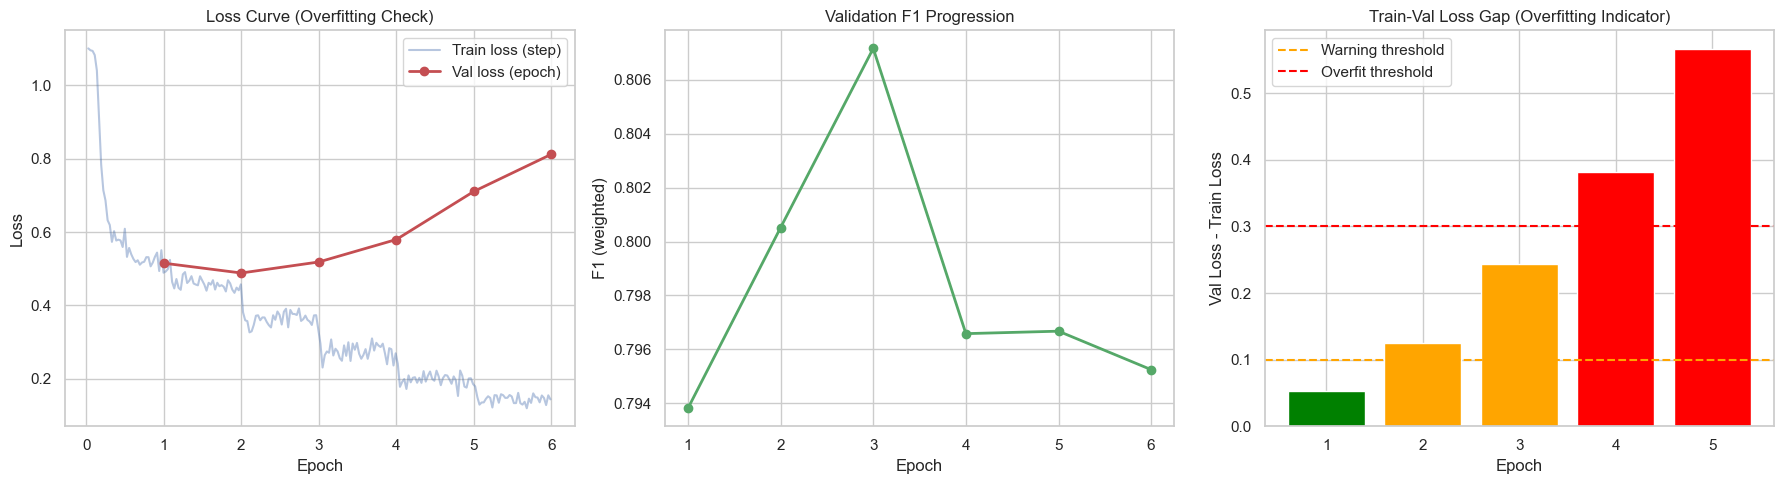

⚠ Overfitting detected: val loss increased from 0.4885 (epoch 2) to 0.8122
  → Best model loaded from epoch 2 (load_best_model_at_end=True)


In [26]:
# Extract training history
log_history = trainer.state.log_history

train_losses = [(entry["epoch"], entry["loss"]) for entry in log_history if "loss" in entry and "eval_loss" not in entry]
eval_entries = [entry for entry in log_history if "eval_loss" in entry]

if eval_entries:
    eval_epochs = [e["epoch"] for e in eval_entries]
    eval_losses = [e["eval_loss"] for e in eval_entries]
    eval_f1s = [e.get("eval_f1", 0) for e in eval_entries]
    eval_acc = [e.get("eval_accuracy", 0) for e in eval_entries]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Loss curves — overfitting detection
    if train_losses:
        t_epochs, t_losses = zip(*train_losses)
        axes[0].plot(t_epochs, t_losses, "b-", alpha=0.4, label="Train loss (step)")
    axes[0].plot(eval_epochs, eval_losses, "r-o", linewidth=2, label="Val loss (epoch)")
    axes[0].set_title("Loss Curve (Overfitting Check)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # 2. F1 progression
    axes[1].plot(eval_epochs, eval_f1s, "g-o", linewidth=2)
    axes[1].set_title("Validation F1 Progression")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("F1 (weighted)")
    axes[1].grid(True)

    # 3. Train vs Val gap
    # Approximate train loss per epoch
    if train_losses:
        epoch_train_losses = {}
        for ep, loss in train_losses:
            ep_int = int(ep)
            epoch_train_losses.setdefault(ep_int, []).append(loss)
        avg_train_losses = {ep: np.mean(losses) for ep, losses in epoch_train_losses.items()}

        common_epochs = sorted(set(int(e) for e in eval_epochs) & set(avg_train_losses.keys()))
        if common_epochs:
            gaps = [eval_losses[int(e)-1] - avg_train_losses[e] for e in common_epochs if int(e)-1 < len(eval_losses)]
            axes[2].bar(common_epochs[:len(gaps)], gaps, color=["green" if g < 0.1 else "orange" if g < 0.3 else "red" for g in gaps])
            axes[2].axhline(y=0.1, color="orange", linestyle="--", label="Warning threshold")
            axes[2].axhline(y=0.3, color="red", linestyle="--", label="Overfit threshold")
            axes[2].set_title("Train-Val Loss Gap (Overfitting Indicator)")
            axes[2].set_xlabel("Epoch")
            axes[2].set_ylabel("Val Loss - Train Loss")
            axes[2].legend()

    plt.tight_layout()
    plt.savefig(ARTIFACT_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Overfitting verdict
    if len(eval_losses) >= 2:
        best_idx = np.argmin(eval_losses)
        if best_idx < len(eval_losses) - 1 and eval_losses[-1] > eval_losses[best_idx] * 1.1:
            print(f"⚠ Overfitting detected: val loss increased from {eval_losses[best_idx]:.4f} (epoch {eval_epochs[best_idx]:.0f}) to {eval_losses[-1]:.4f}")
            print(f"  → Best model loaded from epoch {eval_epochs[best_idx]:.0f} (load_best_model_at_end=True)")
        else:
            print("✓ No significant overfitting detected.")
else:
    print("No evaluation entries found in training log.")

In [27]:
# Catastrophic Forgetting Analysis
# Compare the fine-tuned model's predictions on the SAME samples used for baseline
print("=" * 60)
print("  CATASTROPHIC FORGETTING ANALYSIS")
print("=" * 60)

ft_preds_forget, ft_probs_forget = predict_in_batches(
    trainer.model, tokenizer, BASELINE_SNAPSHOT["texts"],
    batch_size=CONFIG["eval_batch_size"],
)

true_labels = BASELINE_SNAPSHOT["true_labels"]
baseline_preds_snap = BASELINE_SNAPSHOT["preds"]

# Accuracy comparison
baseline_acc = accuracy_score(true_labels, baseline_preds_snap)
ft_acc = accuracy_score(true_labels, ft_preds_forget)

print(f"\nBaseline accuracy (before FT): {baseline_acc:.4f}")
print(f"Fine-tuned accuracy (same samples): {ft_acc:.4f}")
print(f"Delta: {ft_acc - baseline_acc:+.4f}")

# Per-sample forgetting: cases where baseline was correct but fine-tuned is wrong
baseline_correct = (baseline_preds_snap == true_labels)
ft_correct = (ft_preds_forget == true_labels)

forgotten = baseline_correct & ~ft_correct  # was right, now wrong
learned = ~baseline_correct & ft_correct     # was wrong, now right

print(f"\nPer-sample analysis (n={len(true_labels)})")
print(f"  Retained (correct → correct): {(baseline_correct & ft_correct).sum()}")
print(f"  Learned  (wrong → correct):   {learned.sum()}")
print(f"  Forgotten (correct → wrong):  {forgotten.sum()}")
print(f"  Still wrong:                  {(~baseline_correct & ~ft_correct).sum()}")

forgetting_rate = forgotten.sum() / max(baseline_correct.sum(), 1)
print(f"\nForgetting rate: {forgetting_rate:.2%}")
if forgetting_rate > 0.15:
    print("  ⚠ HIGH forgetting — consider lower LR, fewer epochs, or freezing lower layers")
elif forgetting_rate > 0.05:
    print("  ~ MODERATE forgetting — acceptable for domain adaptation")
else:
    print("  ✓ LOW forgetting — fine-tuning preserved base knowledge well")

  CATASTROPHIC FORGETTING ANALYSIS


Inference: 100%|██████████| 8/8 [00:09<00:00,  1.24s/it]


Baseline accuracy (before FT): 0.3420
Fine-tuned accuracy (same samples): 0.8000
Delta: +0.4580

Per-sample analysis (n=500)
  Retained (correct → correct): 157
  Learned  (wrong → correct):   243
  Forgotten (correct → wrong):  14
  Still wrong:                  86

Forgetting rate: 8.19%
  ~ MODERATE forgetting — acceptable for domain adaptation


---
## Phase 7: Standard Evaluation Framework

Comprehensive evaluation applicable to any classification model:
1. Overall metrics (accuracy, precision, recall, F1, ROC-AUC)
2. Per-class performance breakdown
3. Confusion matrix
4. Confidence calibration analysis
5. Error analysis with examples

In [28]:
# Full test set evaluation
pred_output = trainer.predict(ds_test_enc)
test_logits = pred_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_probs = torch.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_true = np.array(ds_test_enc["labels"])

print("=" * 60)
print("  FINE-TUNED MODEL — FULL TEST SET RESULTS")
print("=" * 60)
print()
print(classification_report(test_true, test_preds, target_names=LABEL_NAMES, digits=4))

# ROC-AUC
try:
    auc = roc_auc_score(test_true, test_probs, multi_class="ovr", average="weighted")
    print(f"Weighted ROC-AUC: {auc:.4f}")
except ValueError as e:
    print(f"ROC-AUC: skipped ({e})")

  FINE-TUNED MODEL — FULL TEST SET RESULTS

              precision    recall  f1-score   support

    negative     0.7726    0.8128    0.7922      2884
     neutral     0.7194    0.6855    0.7021      2817
    positive     0.8968    0.8916    0.8942      2981

    accuracy                         0.7985      8682
   macro avg     0.7963    0.7966    0.7961      8682
weighted avg     0.7980    0.7985    0.7980      8682

Weighted ROC-AUC: 0.9319


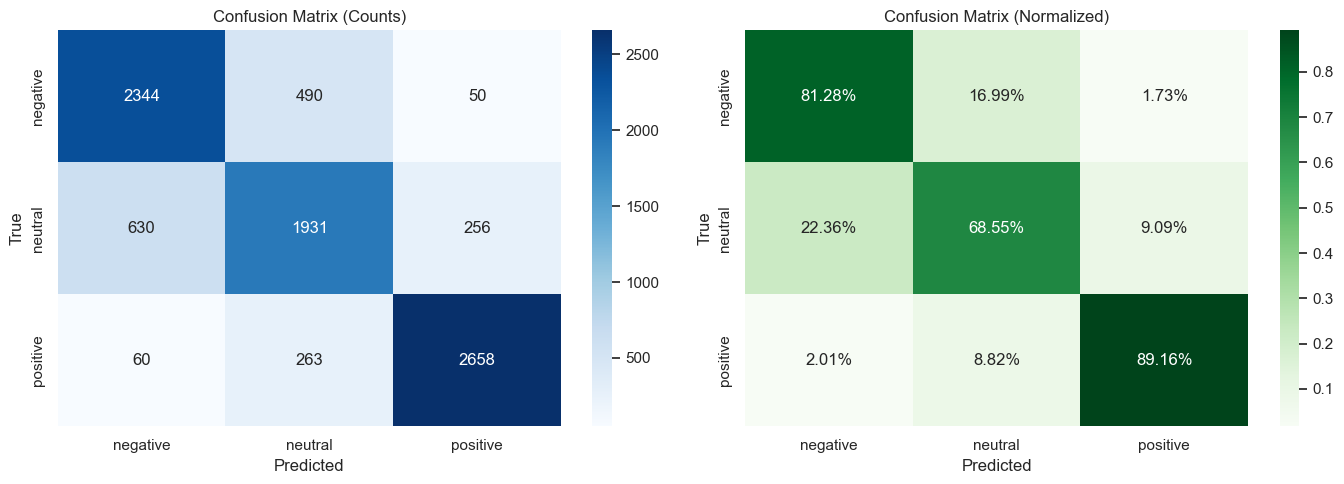

In [29]:
cm = confusion_matrix(test_true, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(
    cm_norm, annot=True, fmt=".2%", cmap="Greens",
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix (Normalized)")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

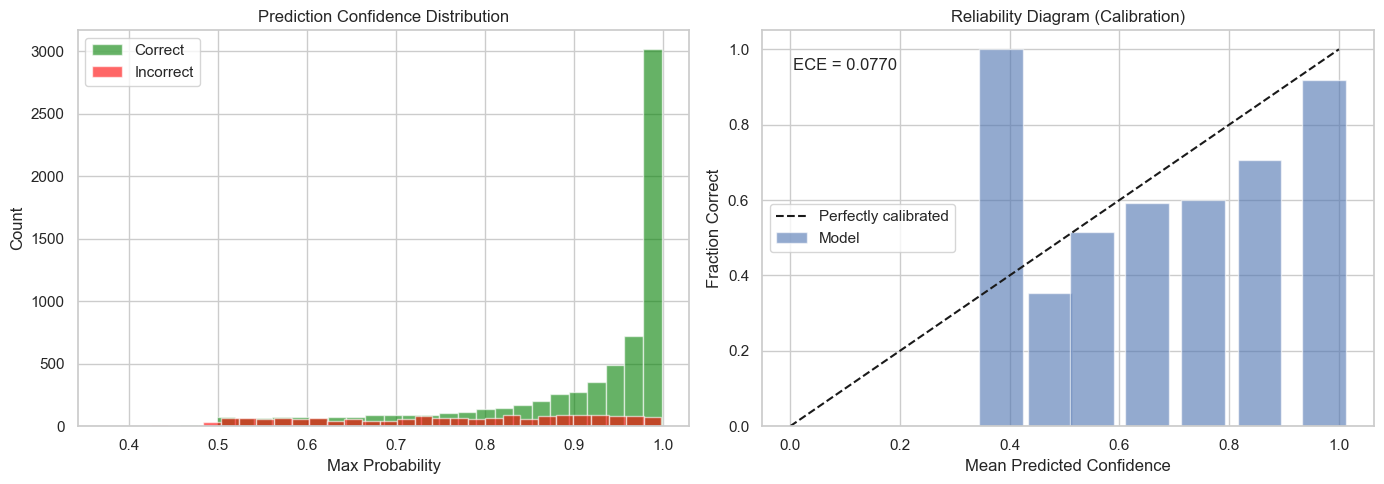

Expected Calibration Error (ECE): 0.0770
  ~ Moderately calibrated — consider temperature scaling for production


In [30]:
# Confidence Calibration Analysis
max_probs = test_probs.max(axis=1)

correct_mask = test_preds == test_true
incorrect_mask = ~correct_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Confidence distribution for correct vs incorrect
axes[0].hist(max_probs[correct_mask], bins=30, alpha=0.6, label="Correct", color="green")
axes[0].hist(max_probs[incorrect_mask], bins=30, alpha=0.6, label="Incorrect", color="red")
axes[0].set_title("Prediction Confidence Distribution")
axes[0].set_xlabel("Max Probability")
axes[0].set_ylabel("Count")
axes[0].legend()

# 2. Reliability diagram (calibration curve)
n_bins = 10
bin_edges = np.linspace(0, 1, n_bins + 1)
bin_accs = []
bin_confs = []
bin_counts = []

for i in range(n_bins):
    mask = (max_probs >= bin_edges[i]) & (max_probs < bin_edges[i + 1])
    if mask.sum() > 0:
        bin_accs.append(correct_mask[mask].mean())
        bin_confs.append(max_probs[mask].mean())
        bin_counts.append(mask.sum())

axes[1].plot([0, 1], [0, 1], "k--", label="Perfectly calibrated")
axes[1].bar(bin_confs, bin_accs, width=0.08, alpha=0.6, label="Model")
axes[1].set_title("Reliability Diagram (Calibration)")
axes[1].set_xlabel("Mean Predicted Confidence")
axes[1].set_ylabel("Fraction Correct")
axes[1].legend()

# Expected Calibration Error
total = sum(bin_counts)
ece = sum(abs(acc - conf) * count / total for acc, conf, count in zip(bin_accs, bin_confs, bin_counts))
axes[1].text(0.05, 0.9, f"ECE = {ece:.4f}", transform=axes[1].transAxes, fontsize=12)

plt.tight_layout()
plt.savefig(ARTIFACT_DIR / "calibration_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Expected Calibration Error (ECE): {ece:.4f}")
if ece < 0.05:
    print("  ✓ Well calibrated")
elif ece < 0.15:
    print("  ~ Moderately calibrated — consider temperature scaling for production")
else:
    print("  ⚠ Poorly calibrated — apply temperature scaling before deployment")

In [31]:
# Per-class performance deep dive
precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
    test_true, test_preds, average=None, zero_division=0,
)

per_class_df = pd.DataFrame({
    "Class": LABEL_NAMES,
    "Precision": precision_pc,
    "Recall": recall_pc,
    "F1": f1_pc,
    "Support": support_pc,
    "Avg Confidence (correct)": [
        max_probs[(test_preds == i) & correct_mask].mean() if ((test_preds == i) & correct_mask).sum() > 0 else 0
        for i in range(NUM_LABELS)
    ],
    "Avg Confidence (incorrect)": [
        max_probs[(test_preds == i) & incorrect_mask].mean() if ((test_preds == i) & incorrect_mask).sum() > 0 else 0
        for i in range(NUM_LABELS)
    ],
})

print("Per-Class Analysis:")
print(per_class_df.to_string(index=False, float_format="%.4f"))

# Flag weak classes
weak_classes = per_class_df[per_class_df["F1"] < 0.7]
if len(weak_classes) > 0:
    print(f"\n⚠ Weak classes (F1 < 0.70):")
    for _, row in weak_classes.iterrows():
        print(f"  {row['Class']}: F1={row['F1']:.4f}, Support={int(row['Support'])}")
    print("  → Consider: more training data, focal loss, or class-specific augmentation")
else:
    print("\n✓ All classes above F1=0.70 threshold.")

Per-Class Analysis:
   Class  Precision  Recall     F1  Support  Avg Confidence (correct)  Avg Confidence (incorrect)
negative     0.7726  0.8128 0.7922     2884                    0.9003                      0.7639
 neutral     0.7194  0.6855 0.7021     2817                    0.8249                      0.7387
positive     0.8968  0.8916 0.8942     2981                    0.9639                      0.8132

✓ All classes above F1=0.70 threshold.


In [32]:
# Error analysis — inspect misclassified examples
test_texts_list = df_test_clean["CleanText"].values[:len(test_preds)]

error_df = pd.DataFrame({
    "text": test_texts_list,
    "true_label": [LABEL_NAMES[t] for t in test_true],
    "pred_label": [LABEL_NAMES[p] for p in test_preds],
    "confidence": max_probs,
    "correct": correct_mask,
})

errors = error_df[~error_df["correct"]].copy()
print(f"Total errors: {len(errors)} / {len(error_df)} ({len(errors)/len(error_df)*100:.1f}%)")
print(f"\nError breakdown (true → predicted):")
print(errors.groupby(["true_label", "pred_label"]).size().sort_values(ascending=False).to_string())

# High-confidence errors (most concerning)
high_conf_errors = errors[errors["confidence"] > 0.8].sort_values("confidence", ascending=False)
print(f"\nHigh-confidence errors (confidence > 0.8): {len(high_conf_errors)}")
for _, row in high_conf_errors.head(5).iterrows():
    print(f"\n  TRUE: {row['true_label']} | PRED: {row['pred_label']} | CONF: {row['confidence']:.3f}")
    print(f"  TEXT: {row['text'][:300]}...")

Total errors: 1749 / 8682 (20.1%)

Error breakdown (true → predicted):
true_label  pred_label
neutral     negative      630
negative    neutral       490
positive    neutral       263
neutral     positive      256
positive    negative       60
negative    positive       50

High-confidence errors (confidence > 0.8): 806

  TRUE: neutral | PRED: positive | CONF: 0.998
  TEXT: best organic seasoning this is the best organic seasoning that i've ever used. in fact we've been using it for about 10 years now. the flavor is perfect with everything from fish, meats, and vegetables and so on! no msg. many, many benefits to this product!...

  TRUE: neutral | PRED: positive | CONF: 0.998
  TEXT: best candy on the planet! i simply enjoyed reliving the days again when i was a young girl with this nostalgic candy package. it was simply everything i expected and more! i would recommend it to others and order it again!...

  TRUE: neutral | PRED: positive | CONF: 0.997
  TEXT: very tasty have been lo

---
## Phase 8: Export for Multi-Agentic System Integration

Save artifacts in a format that an agent framework can load and invoke:
1. Model + tokenizer files
2. Standalone inference wrapper class
3. Model card with metadata
4. Experiment summary JSON

In [33]:
model_dir = ARTIFACT_DIR / "final_model"
model_dir.mkdir(parents=True, exist_ok=True)

trainer.save_model(str(model_dir))
tokenizer.save_pretrained(str(model_dir))

print(f"Model saved to: {model_dir}")
print(f"Contents: {[f.name for f in model_dir.iterdir()]}")

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.63it/s]

Model saved to: /Users/jatindersingh/work_data/mkt-ai/experimentation/artifacts/distilbert_sentiment_production/final_model
Contents: ['model.safetensors', 'tokenizer_config.json', 'config.json', 'tokenizer.json', 'training_args.bin']


In [34]:
# Standalone inference wrapper for agentic integration
inference_code = '''\
"""Sentiment analysis inference wrapper for multi-agentic system integration."""
import os
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification


class SentimentAgent:
    """Production sentiment classifier for agentic pipelines."""

    LABEL_NAMES = ["negative", "neutral", "positive"]

    def __init__(self, model_path: str, device: str = None):
        if device is None:
            if torch.backends.mps.is_available():
                device = "mps"
            elif torch.cuda.is_available():
                device = "cuda"
            else:
                device = "cpu"

        self.device = torch.device(device)
        self.tokenizer = AutoTokenizer.from_pretrained(model_path, cache_dir=os.getenv("HF_HOME"))
        self.model = AutoModelForSequenceClassification.from_pretrained(model_path, cache_dir=os.getenv("HF_HOME"))
        self.model.to(self.device)
        self.model.eval()

    def predict(self, text: str) -> dict:
        """Single text prediction with confidence scores."""
        inputs = self.tokenizer(
            text, return_tensors="pt", truncation=True,
            max_length=256, padding=True,
        )
        inputs = {k: v.to(self.device) for k, v in inputs.items()}

        with torch.no_grad():
            logits = self.model(**inputs).logits
            probs = F.softmax(logits, dim=-1)[0].cpu().numpy()

        pred_idx = int(probs.argmax())
        return {
            "label": self.LABEL_NAMES[pred_idx],
            "confidence": float(probs[pred_idx]),
            "scores": {name: float(probs[i]) for i, name in enumerate(self.LABEL_NAMES)},
        }

    def predict_batch(self, texts: list[str], batch_size: int = 32) -> list[dict]:
        """Batch prediction for throughput."""
        results = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i + batch_size]
            inputs = self.tokenizer(
                batch, return_tensors="pt", truncation=True,
                max_length=256, padding=True,
            )
            inputs = {k: v.to(self.device) for k, v in inputs.items()}

            with torch.no_grad():
                logits = self.model(**inputs).logits
                probs = F.softmax(logits, dim=-1).cpu().numpy()

            for j, p in enumerate(probs):
                pred_idx = int(p.argmax())
                results.append({
                    "label": self.LABEL_NAMES[pred_idx],
                    "confidence": float(p[pred_idx]),
                    "scores": {name: float(p[k]) for k, name in enumerate(self.LABEL_NAMES)},
                })
        return results

    def __call__(self, text: str) -> dict:
        return self.predict(text)
'''

wrapper_path = model_dir / "sentiment_agent.py"
wrapper_path.write_text(inference_code)
print(f"Inference wrapper saved: {wrapper_path}")

Inference wrapper saved: /Users/jatindersingh/work_data/mkt-ai/experimentation/artifacts/distilbert_sentiment_production/final_model/sentiment_agent.py


In [35]:
# Verify the inference wrapper works
import importlib.util

spec = importlib.util.spec_from_file_location("sentiment_agent", str(wrapper_path))
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)

agent = mod.SentimentAgent(str(model_dir))

test_samples = [
    "This product is absolutely amazing, best purchase I ever made!",
    "Terrible quality, broke after one day. Total waste of money.",
    "It's okay, nothing special but does the job.",
    "The shipping was fast but the product quality could be better.",
]

print("Inference wrapper verification:")
for text in test_samples:
    result = agent(text)
    print(f"  [{result['label']:8s}] (conf={result['confidence']:.3f}) {text[:80]}")

# Batch prediction test
batch_results = agent.predict_batch(test_samples)
print(f"\nBatch prediction returned {len(batch_results)} results — ✓")

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 6526.54it/s]


Inference wrapper verification:
  [positive] (conf=0.998) This product is absolutely amazing, best purchase I ever made!
  [negative] (conf=0.994) Terrible quality, broke after one day. Total waste of money.
  [neutral ] (conf=0.955) It's okay, nothing special but does the job.
  [neutral ] (conf=0.762) The shipping was fast but the product quality could be better.

Batch prediction returned 4 results — ✓


In [36]:
# Save experiment summary
final_metrics = {
    "accuracy": accuracy_score(test_true, test_preds),
}
p, r, f, _ = precision_recall_fscore_support(test_true, test_preds, average="weighted", zero_division=0)
final_metrics.update({"precision": p, "recall": r, "f1": f})
try:
    final_metrics["roc_auc"] = roc_auc_score(test_true, test_probs, multi_class="ovr", average="weighted")
except ValueError:
    pass
final_metrics["ece"] = ece
final_metrics["forgetting_rate"] = float(forgetting_rate)

experiment_summary = {
    "experiment_name": CONFIG["experiment_name"],
    "timestamp": datetime.now().isoformat(),
    "config": {k: str(v) if isinstance(v, Path) else v for k, v in CONFIG.items()},
    "data": {
        "train_samples": len(ds_train_enc),
        "val_samples": len(ds_val_enc),
        "test_samples": len(ds_test_enc),
        "num_labels": NUM_LABELS,
        "label_names": LABEL_NAMES,
    },
    "training": {
        "epochs_completed": trainer.state.epoch,
        "early_stopped": trainer.state.epoch < CONFIG["num_epochs"],
        "training_time_minutes": round(train_duration / 60, 2),
    },
    "test_metrics": {k: round(v, 4) for k, v in final_metrics.items()},
    "per_class_f1": {name: round(f1_pc[i], 4) for i, name in enumerate(LABEL_NAMES)},
    "model_path": str(model_dir),
    "integration": {
        "wrapper_class": "SentimentAgent",
        "wrapper_path": str(wrapper_path),
        "usage": "agent = SentimentAgent(model_path); result = agent.predict(text)",
    },
}

summary_path = ARTIFACT_DIR / "experiment_summary.json"
with open(summary_path, "w") as f:
    json.dump(experiment_summary, f, indent=2)

# Also save per-class metrics CSV
per_class_df.to_csv(ARTIFACT_DIR / "per_class_metrics.csv", index=False)

print(f"Experiment summary: {summary_path}")
print(f"\nFinal Test Metrics:")
for k, v in final_metrics.items():
    print(f"  {k:20s}: {v:.4f}")

Experiment summary: /Users/jatindersingh/work_data/mkt-ai/experimentation/artifacts/distilbert_sentiment_production/experiment_summary.json

Final Test Metrics:
  accuracy            : 0.7985
  precision           : 0.7980
  recall              : 0.7985
  f1                  : 0.7980
  roc_auc             : 0.9319
  ece                 : 0.0770
  forgetting_rate     : 0.0819


In [37]:
model_card = f"""# DistilBERT Sentiment Classifier — Marketing Domain

## Model Details
- **Base model**: distilbert-base-uncased
- **Task**: 3-class sentiment classification (negative, neutral, positive)
- **Domain**: Product/marketing reviews
- **Fine-tuned on**: {len(ds_train_enc):,} training samples

## Performance (Test Set: {len(ds_test_enc):,} samples)
| Metric | Value |
|--------|-------|
| Accuracy | {final_metrics['accuracy']:.4f} |
| F1 (weighted) | {final_metrics['f1']:.4f} |
| ROC-AUC | {final_metrics.get('roc_auc', 'N/A')} |
| ECE | {final_metrics['ece']:.4f} |
| Forgetting Rate | {final_metrics['forgetting_rate']:.2%} |

## Per-Class F1
| Class | F1 |
|-------|----|
{''.join(f'| {name} | {f1_pc[i]:.4f} |' + chr(10) for i, name in enumerate(LABEL_NAMES))}

## Usage in Multi-Agentic System
```python
from sentiment_agent import SentimentAgent

agent = SentimentAgent("{model_dir}")
result = agent.predict("Great product, highly recommend!")
# {{'label': 'positive', 'confidence': 0.95, 'scores': {{...}}}}
```

## Training Config
- Epochs: {trainer.state.epoch} (early stopping patience={CONFIG['early_stopping_patience']})
- LR: {CONFIG['learning_rate']}, warmup: {CONFIG['warmup_ratio']}
- Loss: {'Focal' if CONFIG['use_focal_loss'] else 'Weighted CE'}
- Gradient clipping: {CONFIG['max_grad_norm']}
"""

(model_dir / "MODEL_CARD.md").write_text(model_card)
print("Model card saved.")
print(model_card)

Model card saved.
# DistilBERT Sentiment Classifier — Marketing Domain

## Model Details
- **Base model**: distilbert-base-uncased
- **Task**: 3-class sentiment classification (negative, neutral, positive)
- **Domain**: Product/marketing reviews
- **Fine-tuned on**: 57,711 training samples

## Performance (Test Set: 8,682 samples)
| Metric | Value |
|--------|-------|
| Accuracy | 0.7985 |
| F1 (weighted) | 0.7980 |
| ROC-AUC | 0.9318531430052228 |
| ECE | 0.0770 |
| Forgetting Rate | 8.19% |

## Per-Class F1
| Class | F1 |
|-------|----|
| negative | 0.7922 |
| neutral | 0.7021 |
| positive | 0.8942 |


## Usage in Multi-Agentic System
```python
from sentiment_agent import SentimentAgent

agent = SentimentAgent("/Users/jatindersingh/work_data/mkt-ai/experimentation/artifacts/distilbert_sentiment_production/final_model")
result = agent.predict("Great product, highly recommend!")
# {'label': 'positive', 'confidence': 0.95, 'scores': {...}}
```

## Training Config
- Epochs: 6.0 (early st

In [38]:
print("=" * 60)
print("  EXPERIMENT COMPLETE")
print("=" * 60)
print(f"\n  Artifact directory: {ARTIFACT_DIR}")
print(f"  Model directory:    {model_dir}")
print()
print("  Saved artifacts:")
for p in sorted(ARTIFACT_DIR.rglob("*")):
    if p.is_file():
        size_kb = p.stat().st_size / 1024
        rel = p.relative_to(ARTIFACT_DIR)
        print(f"    {str(rel):50s} {size_kb:8.1f} KB")
print()
print("  Integration:")
print(f"    from sentiment_agent import SentimentAgent")
print(f"    agent = SentimentAgent('{model_dir}')")
print(f"    result = agent.predict('your text here')")
print(f"    results = agent.predict_batch(['text1', 'text2'])")

  EXPERIMENT COMPLETE

  Artifact directory: /Users/jatindersingh/work_data/mkt-ai/experimentation/artifacts/distilbert_sentiment_production
  Model directory:    /Users/jatindersingh/work_data/mkt-ai/experimentation/artifacts/distilbert_sentiment_production/final_model

  Saved artifacts:
    .DS_Store                                               6.0 KB
    calibration_analysis.png                               81.5 KB
    checkpoints/checkpoint-10824/config.json                0.8 KB
    checkpoints/checkpoint-10824/model.safetensors     261558.2 KB
    checkpoints/checkpoint-10824/optimizer.pt          523174.8 KB
    checkpoints/checkpoint-10824/rng_state.pth             14.1 KB
    checkpoints/checkpoint-10824/scheduler.pt               1.4 KB
    checkpoints/checkpoint-10824/tokenizer.json           695.0 KB
    checkpoints/checkpoint-10824/tokenizer_config.json      0.3 KB
    checkpoints/checkpoint-10824/trainer_state.json        43.0 KB
    checkpoints/checkpoint-10824/traini